In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from qdmlimits.pdf import show_image
from qdmlimits.calibration import make_calibration, check_calibration
from qdmlimits.extraction import pick_color_at, extract_curve_by_color, sort_curve_pixels, smooth_curve, preview_extraction

%matplotlib widget

OUT_DIR = Path('../curves/panda/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

img = show_image('../curves/panda/panda.png')

Image size: 1728 × 1330 px  (width × height)


In [2]:
# Hover over two x-axis ticks and two y-axis ticks in the viewer above
calib = make_calibration(
    px1=1019, px2=1678,  dx1=4, dx2=6, xlog=False,
    py1=929, py2=724,  dy1=1e-44, dy2=1e-43, ylog=True,
)

check_calibration(img, calib)

In [3]:
# Hover over the curve to read (px, py), then fill in below
TOL = 30
color_bgr = pick_color_at(img, px=417, py=430)

Sampled at (417, 430)  RGB=(np.uint8(0), np.uint8(46), np.uint8(246))  BGR=(np.uint8(246), np.uint8(46), np.uint8(0))       


In [9]:
from qdmlimits.extraction import trace_curve
sorted_pix = trace_curve(img, color_bgr, calib, x_min=2, x_max=6, tol=40)
sorted_pix = smooth_curve(sorted_pix, window=200, poly=3)

preview_extraction(img, sorted_pix, name='panda_curve')

  Traced 1314 points from x=2 to x=6.


Saved 1314 points → ../curves/panda/outputs/pandax4t_2025.csv


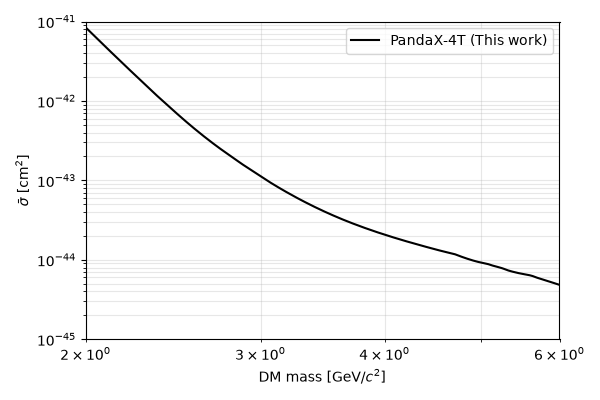

In [10]:
CURVE_NAME = 'pandax4t_2025'  # change per curve

x_data, y_data = calib.to_data(sorted_pix[:, 0], sorted_pix[:, 1])

out_path = OUT_DIR / f'{CURVE_NAME}.csv'
np.savetxt(out_path, np.column_stack([x_data, y_data]),
           delimiter=',', header='x_GeV_per_c2,y_cm2', comments='')
print(f'Saved {len(x_data)} points → {out_path}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_data, y_data, color='black', lw=1.5, label='PandaX-4T (This work)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(2, 6)
ax.set_ylim(1e-45, 1e-41)
ax.set_xlabel(r'DM mass [GeV/$c^2$]')
ax.set_ylabel(r'$\bar{\sigma}$ [cm$^2$]')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()